<a href="https://colab.research.google.com/github/arulselvi-git/arulselvi-codebooster-2026/blob/main/Day2/Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported sucessfully")
print(f"pandas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")

All libraries imported sucessfully
pandas version:2.2.2
sqlite3 version:2.6.0


In [34]:
df=pd.read_csv("student_performance.csv")

In [35]:
print(f"Dataset loaded:{df.shape[0]} students, {df.shape[1]}columns")
print(f"columns:{df.columns.tolist}")
print("\nFirst 3 rows:")
df.head(3)

Dataset loaded:30 students, 13columns
columns:<bound method IndexOpsMixin.tolist of Index(['student_id', 'name', 'age', 'gender', 'department', 'semester',
       'math_score', 'science_score', 'english_score', 'programming_score',
       'attendance_percentage', 'city', 'admission_year'],
      dtype='object')>

First 3 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [36]:
conn=sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    index=False,
    if_exists='replace'
)
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print("database 'college.db' created sucessfully")
print(f"Table 'students' has {count} rows")

database 'college.db' created sucessfully
Table 'students' has 30 rows


In [37]:
def run_query(sql, description="student"):
    if description:
        print(f"\n{'=' * 55}")
        print(f"{description}")
        print(f"{'=' * 55}")

    result = pd.read_sql_query(sql, conn)
    return result

print("Helper function 'run_query' defined successfully")
print("Usage: run_query(sql_string, description_label)")

Helper function 'run_query' defined successfully
Usage: run_query(sql_string, description_label)


In [38]:
query1="""
  SELECT student_id,name,department,math_score,attendance_percentage
  From students
  LIMIT 10
"""

result1=run_query(query1,"Query 1: First 10 students (SELECT+LIMIT)")
print(result1)


Query 1: First 10 students (SELECT+LIMIT)
   student_id          name        department  math_score  \
0        1001  Aarav Sharma  Computer Science          85   
1        1002   Priya Patel  Computer Science          76   
2        1003   Rohit Verma       Electronics          65   
3        1004   Sneha Reddy        Mechanical          70   
4        1005    Arjun Nair  Computer Science          92   
5        1006   Meera Joshi       Electronics          58   
6        1007   Kiran Kumar             Civil          73   
7        1008   Divya Singh  Computer Science          88   
8        1009  Rahul Mishra        Mechanical          62   
9        1010    Ananya Das  Computer Science          95   

   attendance_percentage  
0                     92  
1                     87  
2                     78  
3                     95  
4                     90  
5                     72  
6                     85  
7                     96  
8                     68  
9              

In [39]:
query1="""
  SELECT student_id,name,department,math_score
  From students
  ORDER BY math_score DESC
  LIMIT 5
"""

result1=run_query(query1,"Query 1: top 5 MATH Scores (ORDER BY DESC+LIMIT)")
print(result1)


Query 1: top 5 MATH Scores (ORDER BY DESC+LIMIT)
   student_id            name        department  math_score
0        1010      Ananya Das  Computer Science          95
1        1022     Tanvi Mehta  Computer Science          93
2        1005      Arjun Nair  Computer Science          92
3        1030  Akanksha Yadav  Computer Science          91
4        1018  Swati Kulkarni  Computer Science          90


In [40]:
query1="""
  SELECT student_id,name,department,math_score,programming_score,attendance_percentage
  From students
  WHERE department='Computer Science'
  ORDER BY programming_score DESC
"""

result1=run_query(query1,"Query 1: Computer Science Students (WHERE Filter)")
print(f"\nTotal cs students found: {len(result1)}")
print(result1)


Query 1: Computer Science Students (WHERE Filter)

Total cs students found: 13
    student_id            name        department  math_score  \
0         1010      Ananya Das  Computer Science          95   
1         1022     Tanvi Mehta  Computer Science          93   
2         1005      Arjun Nair  Computer Science          92   
3         1030  Akanksha Yadav  Computer Science          91   
4         1008     Divya Singh  Computer Science          88   
5         1018  Swati Kulkarni  Computer Science          90   
6         1001    Aarav Sharma  Computer Science          85   
7         1025       Amit Bose  Computer Science          86   
8         1013      Suresh Rao  Computer Science          83   
9         1027   Gaurav Shukla  Computer Science          84   
10        1020    Nisha Kapoor  Computer Science          79   
11        1002     Priya Patel  Computer Science          76   
12        1015     Ajay Tiwari  Computer Science          71   

    programming_score  

In [41]:
query1="""
  SELECT name,department,attendance_percentage
  From students
  WHERE attendance_percentage >90
  AND department != 'Civil'
  ORDER BY attendance_percentage DESC
"""

result1=run_query(query1,"Query 1: High Attendance (>90%) Excluding Civil Dept")
print(result1)


Query 1: High Attendance (>90%) Excluding Civil Dept
             name        department  attendance_percentage
0      Ananya Das  Computer Science                     98
1     Tanvi Mehta  Computer Science                     97
2     Divya Singh  Computer Science                     96
3     Sneha Reddy        Mechanical                     95
4  Akanksha Yadav  Computer Science                     95
5  Swati Kulkarni  Computer Science                     94
6    Ritu Agarwal       Electronics                     93
7    Aarav Sharma  Computer Science                     92
8   Kavya Nambiar        Mechanical                     91
9       Amit Bose  Computer Science                     91


In [42]:
query1="""
  SELECT name,department,attendance_percentage
  From students
  WHERE attendance_percentage >93
  AND department != 'Mechanical'
  ORDER BY attendance_percentage DESC
  LIMIT 3
"""

result1=run_query(query1,"Query 1: High Attendance (>93%) Excluding Mechanical Dept")
print(result1)


Query 1: High Attendance (>93%) Excluding Mechanical Dept
          name        department  attendance_percentage
0   Ananya Das  Computer Science                     98
1  Tanvi Mehta  Computer Science                     97
2  Divya Singh  Computer Science                     96


In [43]:
query5="""
SELECT
 department ,
 COUNT(*)                      AS num_students,
 ROUND(AVG(math_score),2)            AS avg_math,
 ROUND(AVG(science_score),2)           AS avg_science,
 ROUND(AVG(programming_score),2)       AS avg_programming,
 ROUND(AVG(attendance_percentage),2)    AS avg_attendance

FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

result2=run_query(query5,"Query 5: Department")
print(result2)


Query 5: Department
         department  num_students  avg_math  avg_science  avg_programming  \
0  Computer Science            13     85.62        84.46            89.23   
1        Mechanical             6     71.00        76.50            49.33   
2       Electronics             6     71.00        74.17            61.50   
3             Civil             5     63.40        66.60            40.60   

   avg_attendance  
0           90.69  
1           83.50  
2           80.33  
3           74.60  


In [44]:
query5="""
SELECT
 department ,
 ROUND(AVG(math_score),2)            AS avg_math,
 COUNT(*) AS students
FROM students
GROUP BY department
HAVING AVG(math_score)>70
ORDER BY avg_math DESC
"""

result2=run_query(query5,"Query 5: Departments with avg math >70 (HAVING)")
print(result2)


Query 5: Departments with avg math >70 (HAVING)
         department  avg_math  students
0  Computer Science     85.62        13
1        Mechanical     71.00         6
2       Electronics     71.00         6


In [45]:
query6="""
SELECT
 gender ,
 COUNT(*)                      AS num_students,
 ROUND(AVG(math_score),2)            AS avg_math,
 ROUND(AVG(science_score),2)           AS avg_science,
 ROUND(AVG(programming_score),2)       AS avg_programming,
 ROUND(AVG(attendance_percentage),2)    AS avg_attendance

FROM students
GROUP BY gender
ORDER BY avg_math DESC
"""

result2=run_query(query6,"Query 6: gender-wise performance Analysis")
print(result2)


Query 6: gender-wise performance Analysis
   gender  num_students  avg_math  avg_science  avg_programming  \
0  Female            15     78.47        81.20             70.2   
1    Male            15     73.67        74.47             65.0   

   avg_attendance  
0           88.53  
1           80.47  


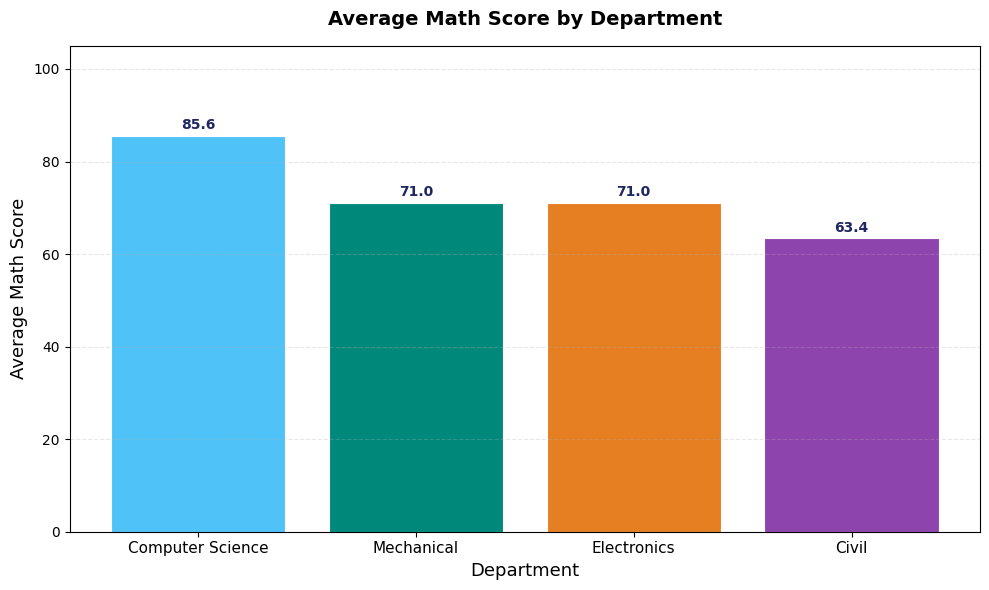

In [46]:
chart1_sql = """
SELECT department, ROUND(AVG(math_score), 2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['#4FC3F7', '#00897B', '#E67E22', '#8E44AD']

bars = ax.bar(
    chart1_data['department'],
    chart1_data['avg_math'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#1E2761'
    )

ax.set_title(
    'Average Math Score by Department',
    fontsize=14,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Department', fontsize=13)
ax.set_ylabel('Average Math Score', fontsize=13)

ax.set_ylim(0, 105)

ax.tick_params(axis='x', labelsize=11)

ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [49]:
query6="""
SELECT
 gender ,
 COUNT(*)                      AS num_students,
 ROUND(AVG(programming_score),2)       AS avg_programming
FROM students
WHERE gender = 'Female'
GROUP BY gender
ORDER BY avg_programming DESC
"""

result2=run_query(query6,"Query 6: gender-wise performance Analysis")
print(result2)


Query 6: gender-wise performance Analysis
   gender  num_students  avg_programming
0  Female            15             70.2


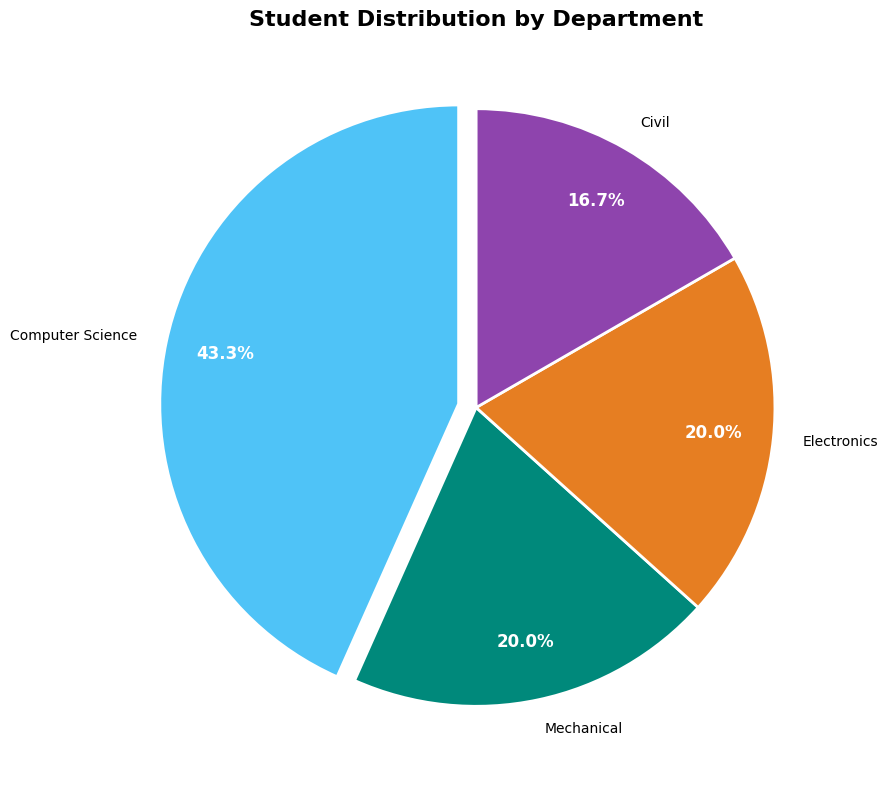

In [50]:
chart1_sql = """
SELECT department, COUNT(*) AS num_students
FROM students
GROUP BY department
ORDER BY num_students DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

labels = chart1_data['department'].tolist()
sizes = chart1_data['num_students'].tolist()

colors = ['#4FC3F7', '#00897B', '#E67E22', '#8E44AD']

explode = [0.06, 0, 0, 0]

fig, ax = plt.subplots(figsize=(9, 9))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax.set_title(
    'Student Distribution by Department',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()